# ERSSTv5 Regrid Inspection

Visual comparison of ERSSTv5 on its native 2° grid vs regridded to CESM2-LE atmospheric grid (192×288).

Run `process_ersst_regrid()` first to generate the regridded file.

In [7]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/lhoffma2/git/slowdown_arctic_seaice")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(sys.path[0])

from src.data.observations.ersst.download import load_ersst

/home/lhoffma2/git/slowdown_arctic_seaice


In [8]:
# ── PATHS ── edit these to match your machine ──────────────────────────────
ERSST_RAW      = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/ersst/sst.mnmean.nc'
ERSST_REGRID   = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/arcticWatch/ersst/sst_regrid_cesm2le.nc'

# Which time step to inspect (0 = Jan 1854, -1 = last)
T_IDX = 1632   # e.g. Jan 1990  (1990-1854)*12 = 1632
# ───────────────────────────────────────────────────────────────────────────

In [9]:
# Load original ERSSTv5
sst_orig, lat_orig, lon_orig, dates = load_ersst(ERSST_RAW)
print(f'Original  : {sst_orig.shape}  grid: {lat_orig.shape} × {lon_orig.shape}')
print(f'Timestep  : {dates[T_IDX].strftime("%Y-%m")}')

Loaded ERSSTv5: (2060, 89, 180) (ntime, nlat, nlon)
  Date range: 1854-01 to 2025-08
  Grid: 89 lat × 180 lon
Original  : (2060, 89, 180)  grid: (89,) × (180,)
Timestep  : 1990-01


In [10]:
# Load regridded ERSSTv5
ds_rg = nc.Dataset(ERSST_REGRID, 'r')
sst_rg   = np.array(ds_rg.variables['sst_obs'])
lat_rg   = np.array(ds_rg.variables['lat_cesm2'])
lon_rg   = np.array(ds_rg.variables['lon_cesm2'])
ds_rg.close()
print(f'Regridded : {sst_rg.shape}  grid: {lat_rg.shape} × {lon_rg.shape}')

/tmp/ipykernel_3191031/1054805828.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sst_rg   = np.array(ds_rg.variables['sst_obs'])


Regridded : (2060, 192, 288)  grid: (192, 288) × (192, 288)


/tmp/ipykernel_3191031/1054805828.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lat_rg   = np.array(ds_rg.variables['lat_cesm2'])
/tmp/ipykernel_3191031/1054805828.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon_rg   = np.array(ds_rg.variables['lon_cesm2'])


/tmp/ipykernel_3191031/2949206331.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


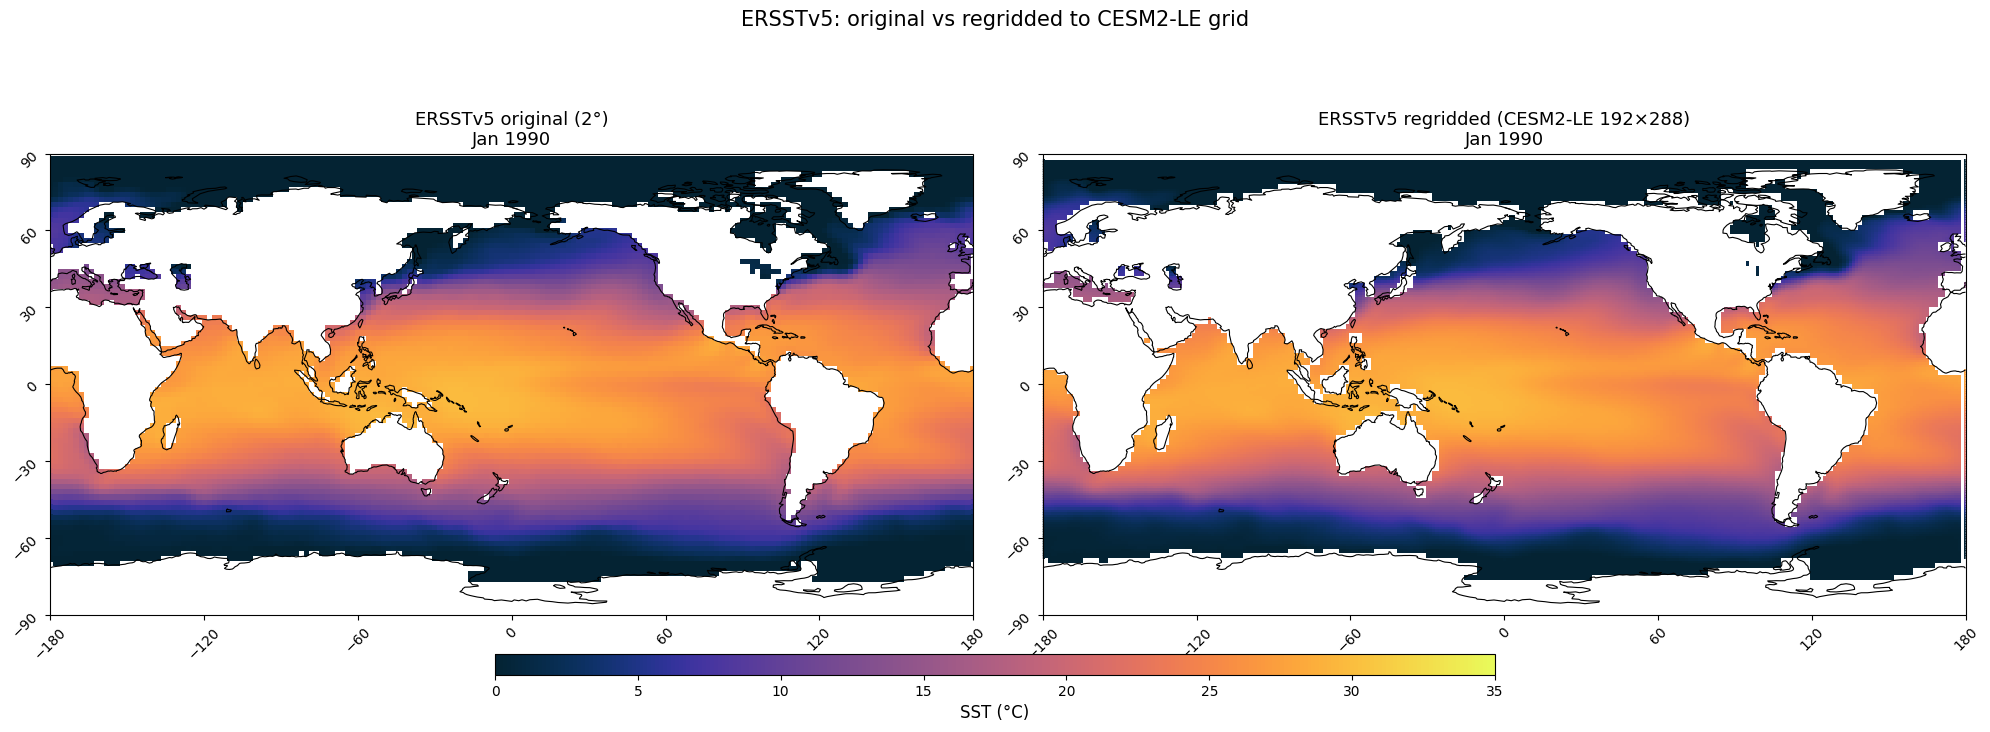

In [13]:
# ── Side-by-side map comparison ────────────────────────────────────────────
datasets = [
    {'data': sst_orig[T_IDX], 'lat': lat_orig, 'lon': lon_orig,
     'title': f'ERSSTv5 original (2°)\n{dates[T_IDX].strftime("%b %Y")}'},
    {'data': sst_rg[T_IDX],   'lat': lat_rg,   'lon': lon_rg,
     'title': f'ERSSTv5 regridded (CESM2-LE 192×288)\n{dates[T_IDX].strftime("%b %Y")}'},
]

fig, axes = plt.subplots(
    1, 2, figsize=(20, 7),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)

for ax, ds in zip(axes, datasets):
    ax.set_global()
    ax.coastlines(linewidth=0.8)
    im = ax.pcolormesh(
        ds['lon'], ds['lat'], ds['data'],
        cmap=cmocean.cm.thermal,
        shading='auto',
        transform=ccrs.PlateCarree()
    )
    im.set_clim(0, 35)
    ax.set_xticks(range(-180, 181, 60))
    ax.set_yticks(range(-90, 91, 30))
    ax.xaxis.set_tick_params(rotation=45)
    ax.yaxis.set_tick_params(rotation=45)
    ax.set_title(ds['title'], fontsize=13)

fig.subplots_adjust(bottom=0.12)
cbar_ax = fig.add_axes([0.25, 0.06, 0.5, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('SST (°C)', fontsize=12)

plt.suptitle('ERSSTv5: original vs regridded to CESM2-LE grid', fontsize=15, y=1.01)
plt.tight_layout()
#plt.savefig('inspect_regrid.png', dpi=150, bbox_inches='tight')
plt.show()